In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
file_path = "/content/Independent_Medical_Reviews.csv"
df = pd.read_csv(file_path)

In [ ]:
# Display basic info
print("Dataset Overview:")
print(df.info())

Dataset Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19245 entries, 0 to 19244
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Reference ID            19245 non-null  object
 1   Report Year             19245 non-null  int64 
 2   Diagnosis Category      19186 non-null  object
 3   Diagnosis Sub Category  17341 non-null  object
 4   Treatment Category      18795 non-null  object
 5   Treatment Sub Category  17977 non-null  object
 6   Determination           19245 non-null  object
 7   Type                    19245 non-null  object
 8   Age Range               18035 non-null  object
 9   Patient Gender          18035 non-null  object
 10  Findings                19225 non-null  object
dtypes: int64(1), object(10)
memory usage: 1.6+ MB
None


In [ ]:
df.shape

(19245, 11)

In [ ]:
# Display the first few rows
df.head()

,Reference ID,Report Year,Diagnosis Category,Diagnosis Sub Category,Treatment Category,Treatment Sub Category,Determination,Type,Age Range,Patient Gender,Findings
0,MN16-22639,2016,Infectious,Hepatitis,Pharmacy/Prescription Drugs,Anti-virals,Overturned Decision of Health Plan,Medical Necessity,41-50,Male,Nature of Statutory Criteria/Case Summary: An ...
1,MN16-22638,2016,Mental,Eating Disorder,Mental Health Treatment,Residential Treatment Center - Admission,Upheld Decision of Health Plan,Medical Necessity,21-30,Female,Nature of Statutory Criteria/Case Summary: An...
2,MN16-22637,2016,Autism Spectrum,Autism-PDD-NOS,Autism Related Treatment,Speech Therapy,Upheld Decision of Health Plan,Medical Necessity,0-10,Female,Nature of Statutory Criteria/Case Summary: Th...
3,EI16-22636,2016,Prevention/Good Health,NaN,"Diagnostic Imaging, Screening and Testing",Mammography,Overturned Decision of Health Plan,Experimental/Investigational,65+,Female,Nature of Statutory Criteria/Case Summary: An ...
4,EI06-5319,2006,Cardiac/Circulatory,NaN,Cardio Vascular,NaN,Upheld Decision of Health Plan,Experimental/Investigational,51-64,Male,Physician 1: The patient is a 62-year-old male...


In [ ]:
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
nltk.download("punkt")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")
nltk.download('punkt_tab')

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
# Select relevant columns (modify if needed)
text_column = "Findings"  # Replace with actual column name
label_column = "Diagnosis Category"  # Replace with actual column name

In [ ]:
# Fill missing values, ensure text format, and remove excessive whitespace
df[text_column] = df[text_column].astype(str).str.strip().replace({"nan": "", "None": ""})

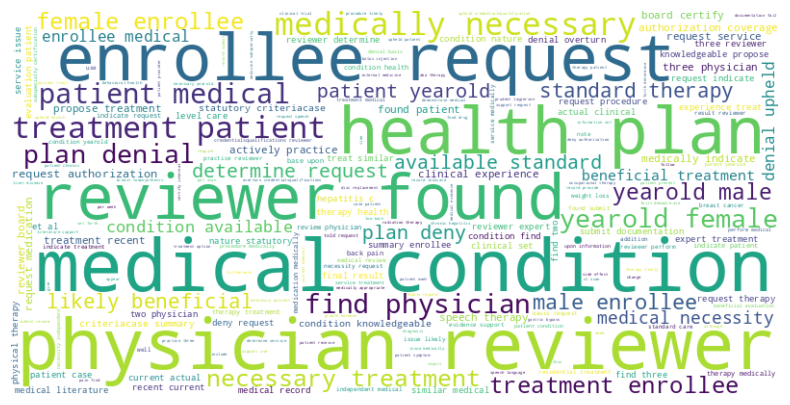

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(df[text_column].dropna())  # Combine all text data from the specified column

# Generate WordCloud
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text)

# Display the WordCloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")  # Hide axes
plt.show()

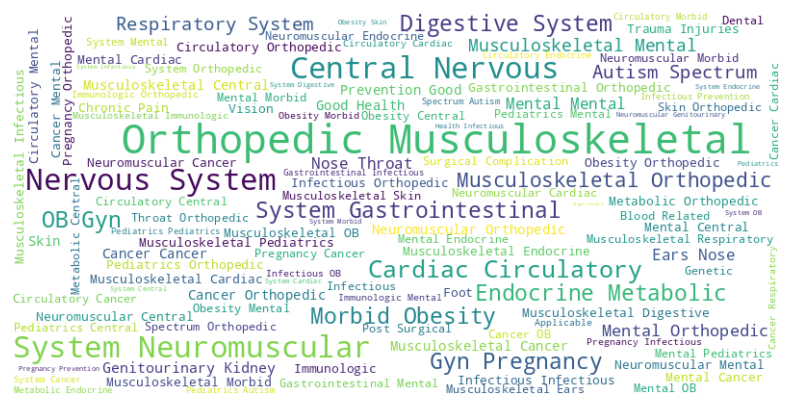

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(df['Diagnosis Category'].dropna())  # Combine all text data from the specified column

# Generate WordCloud
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text)

# Display the WordCloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")  # Hide axes
plt.show()

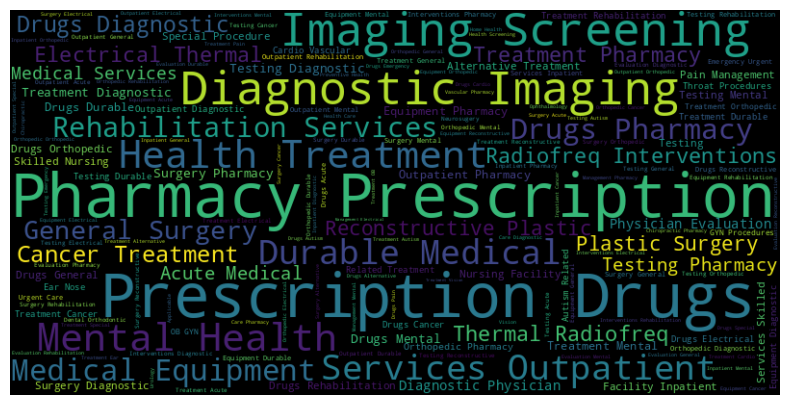

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(df['Treatment Category'].dropna())  # Combine all text data from the specified column

# Generate WordCloud
wordcloud = WordCloud(width=800, height=400, background_color="black").generate(text)

# Display the WordCloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")  # Hide axes
plt.show()

In [ ]:
# Initialize lemmatizer & stopwords
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words("english"))

In [ ]:
# Function to get POS tags for better lemmatization
def get_wordnet_pos(word):
    from nltk.corpus import wordnet
    tag = nltk.pos_tag([word])[0][1][0].upper()
    tag_dict = {"J": wordnet.ADJ, "N": wordnet.NOUN, "V": wordnet.VERB, "R": wordnet.ADV}
    return tag_dict.get(tag, wordnet.NOUN)  # Default to noun if not found

In [ ]:
import nltk

# Download the necessary NLTK data with language specifier 'eng'
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [ ]:
def preprocess_text(text, remove_numbers=True):
    if not isinstance(text, str) or text.strip() == "":  # Handle NaN or empty text
        return ""

    text = text.lower().strip()  # Lowercase + trim spaces
    text = re.sub(r"https?://\S+|www\.\S+", "", text)  # Remove URLs
    if remove_numbers:
        text = re.sub(r"\d+", "", text)  # Remove numbers
    text = re.sub(r"[^a-z\s]", "", text)  # Remove special characters (keep spaces)
    text = re.sub(r"\s+", " ", text)  # Remove extra spaces

    # Tokenization & Lemmatization
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(word, get_wordnet_pos(word)) for word in tokens if word not in stop_words]

    return " ".join(tokens)

# Apply preprocessing
df[text_column] = df[text_column].apply(lambda x: preprocess_text(x, remove_numbers=True))

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.linear_model import LogisticRegression

In [ ]:
from sklearn.model_selection import train_test_split

# Drop NaN values and clean text column
df = df.dropna(subset=[text_column, label_column]).reset_index(drop=True)
df[text_column] = df[text_column].astype(str).str.strip()  # Ensure text is string & remove extra spaces

# Define test size dynamically (adjust based on dataset size)
test_size = 0.15 if df[label_column].nunique() > 2 else 0.2  # Use 15% for multi-class, 20% for binary

# Split dataset using stratified sampling
X_train, X_test, y_train, y_test = train_test_split(
    df[text_column],
    df[label_column],
    test_size=test_size,
    random_state=42,
    stratify=df[label_column],  # Maintain class distribution
    shuffle=True  # Ensures randomness
)

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

# Encode Labels to Numbers
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# TF-IDF Vectorizer
tfidf = TfidfVectorizer(ngram_range=(1,2), max_features=20_000, stop_words="english", sublinear_tf=True)

xgb_model = XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=6, eval_metric="logloss")

# Pipeline
model = Pipeline([
    ("tfidf", tfidf),
    ("classifier", xgb_model)
])

In [ ]:
# Train Model
model.fit(X_train, y_train_encoded)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=20000, ngram_range=(1, 2),
                                 stop_words='english', sublinear_tf=True)),
                ('classifier',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric='logloss',
                               featur...icy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=6, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=None,
                               num_parallel_tree=None,
                               objective='multi:softprob', ...))])

In [ ]:
from sklearn.metrics import accuracy_score

# Predict
y_pred_encoded = model.predict(X_test)

# Convert Encoded Predictions Back to Original Labels
y_pred = label_encoder.inverse_transform(y_pred_encoded)
y_test_decoded = label_encoder.inverse_transform(y_test_encoded)  # Ensure y_test is also decoded

# Evaluate
accuracy = accuracy_score(y_test_decoded, y_pred)
print(f"Model Accuracy: {accuracy:.2f}")

Baseline Model Accuracy: 0.79


In [ ]:
new_text = "The doctor provided excellent medical advice and care."
processed_text = preprocess_text(new_text)

# Predict (outputs a numeric label)
predicted_label_encoded = model.predict([processed_text])[0]

# Convert Numeric Label → Original Text Label
predicted_label = label_encoder.inverse_transform([predicted_label_encoded])[0]

print("Predicted Label:", predicted_label)

Predicted Label: Central Nervous System/ Neuromuscular


In [ ]:
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score

train_predictions = model.predict(X_train)
test_predictions = model.predict(X_test)

train_score = accuracy_score(y_train, train_predictions)
test_score = accuracy_score(y_test, test_predictions)

print(f"Train Score: {train_score:.2f}")
print(f"Test Score: {test_score:.2f}")

# Predict on the test set
y_pred = model.predict(X_test)

# Generate and print the classification report
print(classification_report(y_test, y_pred, zero_division=1))

Train Score: 0.84
Test Score: 0.79
                                       precision    recall  f1-score   support

                      Autism Spectrum       0.88      0.82      0.85        79
                        Blood Related       1.00      0.20      0.33        15
                               Cancer       0.82      0.83      0.83       252
                  Cardiac/Circulatory       0.82      0.83      0.83       145
Central Nervous System/ Neuromuscular       0.71      0.77      0.74       243
                         Chronic Pain       1.00      0.00      0.00        18
                               Dental       0.50      0.27      0.35        11
   Digestive System/ Gastrointestinal       0.82      0.70      0.75       114
                   Ears, Nose, Throat       0.66      0.70      0.68        56
                 Endocrine/ Metabolic       0.90      0.76      0.82       117
                                 Foot       0.86      0.56      0.68        32
                

In [ ]:
from sklearn.metrics import accuracy_score

# Predict on training and test data
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Compute accuracy scores
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

# Print results
print(f"Train Accuracy: {train_accuracy:.2f}")
print(f"Test Accuracy: {test_accuracy:.2f}")

# Check model status
if train_accuracy > 0.90 and test_accuracy < 0.75:
    print("⚠️ Overfitting detected! Your model performs well on training data but poorly on test data.")
elif train_accuracy < 0.80 and test_accuracy < 0.75:
    print("⚠️ Underfitting detected! Your model is too simple and not learning enough patterns.")
elif abs(train_accuracy - test_accuracy) <= 0.05:
    print("✅ Balanced model! Your model is generalizing well.")
else:
    print("🔎 Further tuning required!")


Train Accuracy: 0.84
Test Accuracy: 0.79
🔎 Further tuning required!
